In [5]:
import warnings

warnings.filterwarnings("ignore")

import os  
import sys
parent =  os.path.join(os.getcwd(), 'package', 'synthdid')
dir = os.path.dirname(parent)
sys.path.append(dir)

import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
from scipy.stats import skew, kurtosis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from SyntheticControlMethods import Synth
import itertools
from tqdm import tqdm
import random
from scipy import stats
from synthdid.model import SynthDID
dir = os.path.join(os.getcwd(), 'final_clean')
path2= os.path.join(os.getcwd(), 'simulations_ds')

In [6]:
path = dir + '/patents_dataset.csv'

In [7]:
df = pd.read_csv(path)
df.head()
print(df['country'].unique().tolist(), df.shape, '\n', df['year'].unique().tolist())

['AUT', 'FIN', 'IRL', 'CHE', 'SWE'] (115, 11) 
 [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


In [8]:
df = df[['year', 'country', 'brevets', 'gdp', 'pop', 'NX', 'public_spending']]

In [9]:
df = df[df['country'] == 'IRL']
summary_stats = df.describe().loc[['mean', 'std']].round(3)
df.describe()

,year,brevets,gdp,pop,NX,public_spending
count,23.00000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,2007.00000,5.899679,0.021203,8.357304,0.078396,0.056326
std,6.78233,0.382714,2.313380,0.098324,0.133779,0.050162
min,1996.00000,5.159055,-6.494721,8.195913,-0.132862,-0.023599
25%,2001.50000,5.620342,-0.462444,8.268135,-0.020708,0.021526
50%,2007.00000,6.030685,-0.131003,8.389402,0.085936,0.036250
75%,2012.50000,6.197399,0.168810,8.435707,0.173023,0.092522
max,2018.00000,6.364751,7.219623,8.495031,0.289174,0.151374


In [10]:
class Simulation:
    def __init__(self, path, simulated_countries, seed_val, sim_type, sim_data='normal'):
        self.path = path
        self.simulated_countries = simulated_countries
        self.seed_val = seed_val
        self.sim_type = sim_type
        self.df = None
        self.summary_stats = None
        self.means = None
        self.stds = None
        self.simulated_data = None
        self.df_simulated = None
        self.sim_data = sim_data

    def load_data(self):
        self.df = pd.read_csv(self.path)
        self.df = self.df[['year', 'country', 'brevets', 'gdp', 'pop', 'NX', 'public_spending']]
        self.df = self.df[self.df['country'] == 'IRL']
        self.summary_stats = self.df.describe().T
        self.means = self.summary_stats['mean']
        self.stds = self.summary_stats['std']

    def simulateData(self):
        """Simulate data frome normal distribution"""
        num_simulations = self.simulated_countries
        countries = [f's{i + 1}' for i in range(num_simulations)]
        years = np.arange(1999, 2020)
        total_observations = num_simulations * len(years)
        country_year_pairs = list(itertools.product(countries, years))
        countries_expanded, years_expanded = zip(*country_year_pairs)
        
        np.random.seed(self.seed_val)
        self.simulated_data = {
            'country': countries_expanded,
            'year': years_expanded,
            'brevets': np.random.normal(self.means['brevets'], self.stds['brevets'], total_observations).astype(int),
            'gdp': np.random.normal(self.means['gdp'] , self.stds['gdp'], total_observations),
            'pop': np.random.normal(self.means['pop'] , self.stds['pop'], total_observations),
            'NX': np.random.normal(self.means['NX'] , self.stds['NX'], total_observations),
            'public_spending': np.random.normal(self.means['public_spending'] , self.stds['public_spending'], total_observations)
        }
        
    def simulateHetero_data(self):
        """Simulate Heteroscedastic data."""
        num_simulations = self.simulated_countries
        countries = [f's{i + 1}' for i in range(num_simulations)]
        years = np.arange(1999, 2020)
        total_observations = num_simulations * len(years)
        country_year_pairs = list(itertools.product(countries, years))
        countries_expanded, years_expanded = zip(*country_year_pairs)

        np.random.seed(self.seed_val * 2 - 1)
        epsilon0 = np.random.normal(0, np.random.uniform(0.05, 0.15))
        np.random.seed(self.seed_val * 3 - 2)
        epsilon1 = np.random.normal(0, np.random.uniform(0.05, 0.15))
        np.random.seed(self.seed_val * 4 - 3)
        epsilon2 = np.random.normal(0, np.random.uniform(0.05, 0.15))
        np.random.seed(self.seed_val * 5 - 4)
        epsilon3 = np.random.normal(0, np.random.uniform(0.05, 0.15))

        np.random.seed(self.seed_val)
        self.simulated_data = {
            'country': countries_expanded,
            'year': years_expanded,
            'brevets': np.random.normal(
                self.means['brevets'], 
                self.stds['brevets'], 
                total_observations
            ).astype(int),
            
            # Hétéroscédasticité dépendant de gdp lui-même
            'gdp': np.random.normal(
                self.means['gdp'] + epsilon0, 
                np.abs(self.means['gdp']) * self.stds['gdp'],  # Variance proportionnelle à gdp
                total_observations
            ),
            
            # Hétéroscédasticité dépendant de pop elle-même
            'pop': np.random.normal(
                self.means['pop'] + epsilon1, 
                np.abs(self.means['pop']) * self.stds['pop'],  # Variance proportionnelle à pop
                total_observations
            ),
            
            # Hétéroscédasticité dépendant de NX lui-même
            'NX': np.random.normal(
                self.means['NX'] + epsilon2, 
                np.abs(self.means['NX']) * self.stds['NX'],  # Variance proportionnelle à NX
                total_observations
            ),
            
            # Hétéroscédasticité dépendant de public_spending lui-même
            'public_spending': np.random.normal(
                self.means['public_spending'] + epsilon3, 
                np.abs(self.means['public_spending']) * self.stds['public_spending'],  # Variance proportionnelle à public_spending
                total_observations
            )
        }

    def simulateCorrelatedData(self):
        """Simulate Correlated Data with Multivariate Normal Distribution."""
        num_simulations = self.simulated_countries
        countries = [f's{i + 1}' for i in range(num_simulations)]
        years = np.arange(1999, 2020)
        total_observations = num_simulations * len(years)
        country_year_pairs = list(itertools.product(countries, years))
        countries_expanded, years_expanded = zip(*country_year_pairs)

        np.random.seed(self.seed_val)

        # Define the variables
        variables = ['brevets', 'gdp', 'pop', 'NX', 'public_spending']
        means = [self.means[var] for var in variables]
        stds = [self.stds[var] for var in variables]

        # Initialize the correlation matrix
        n_vars = len(variables)
        correlation_matrix = np.eye(n_vars)

        # Generate random strong correlations between -0.9 and -0.7 or 0.7 and 0.9
        for i in range(n_vars):
            for j in range(i + 1, n_vars):
                # Randomly choose positive or negative correlation
                sign = np.random.choice([-1, 1])
                # Randomly choose correlation magnitude between 0.7 and 0.9
                corr_magnitude = np.random.uniform(0.7, 0.9)
                corr_value = sign * corr_magnitude
                # Assign to the correlation matrix symmetrically
                correlation_matrix[i, j] = corr_value
                correlation_matrix[j, i] = corr_value

        # Ensure the correlation matrix is positive semi-definite
        # If not, adjust it to the nearest positive semi-definite matrix
        eigenvalues = np.linalg.eigvals(correlation_matrix)
        if np.all(eigenvalues > 0):
            # The matrix is positive definite, proceed
            pass
        else:
            # Adjust the matrix to be positive semi-definite
            correlation_matrix = self.near_psd(correlation_matrix)

        # Build the covariance matrix
        covariance_matrix = np.outer(stds, stds) * correlation_matrix

        # Generate multivariate normal data
        data = np.random.multivariate_normal(means, covariance_matrix, total_observations)

        # Build the data dictionary
        self.simulated_data = {
            'country': countries_expanded,
            'year': years_expanded,
            'brevets': data[:, 0].astype(int),
            'gdp': data[:, 1],
            'pop': data[:, 2],
            'NX': data[:, 3],
            'public_spending': data[:, 4]
        }

    def near_psd(self, A, epsilon=0):
        """Adjusts a matrix to be the nearest positive semi-definite matrix."""
        # Compute the symmetric part of A
        A_sym = (A + A.T) / 2
        # Perform eigenvalue decomposition
        eigval, eigvec = np.linalg.eigh(A_sym)
        # Adjust eigenvalues to be non-negative
        eigval[eigval < epsilon] = epsilon
        # Reconstruct the matrix
        A_psd = eigvec @ np.diag(eigval) @ eigvec.T
        # Ensure the diagonal is 1 (since it's a correlation matrix)
        A_psd = A_psd / np.sqrt(np.outer(np.diag(A_psd), np.diag(A_psd)))
        return A_psd


    def simulationDf(self):
        self.df_simulated = pd.DataFrame(self.simulated_data)
        self.df = pd.concat([self.df, self.df_simulated], ignore_index=True).drop_duplicates().reset_index(drop=True)
        self.df['country_code'] = pd.factorize(self.df['country'])[0] + 1
        self.df.rename(columns={'country_code': 'state'}, inplace=True)

    def prepare_data_for_sdid(self):
        controls = self.df.copy()
        controls.drop(columns=['country', 'brevets'], inplace=True)
        controls = controls.pivot(index='state', columns="year").T

        self.df.drop(columns=['country'], inplace=True)
        self.df = self.df.pivot(index='state', columns="year")['brevets'].T

        return controls

    def run_sdid(self, controls):
        PRE_TEREM = [1999, 2015]
        POST_TEREM = [2016, 2019]
        TREATMENT = [3]

        sdid = SynthDID(self.df, PRE_TEREM, POST_TEREM, TREATMENT, control_units=controls)
        sdid.fit(zeta_type="base", sparce_estimation=True)

        sdidsummary = sdid.summary(model='cleansdid')
        scsummary = sdid.summary(model='cleansc')
        didsummary = sdid.summary(model='cleandid')
        predicted = sdid.sdid_trajectory()
        observed = sdid.target_y()
        rmspe = ((observed - predicted) ** 2).mean() ** 0.5
        rmspe = round(rmspe, 2)
        outcome = sdid.sc_potentical_outcome()

        if self.sim_type == 'did':
            return [round(didsummary, 2), rmspe]
        elif self.sim_type == 'sc':
            return [round(scsummary, 2), rmspe]
        else:
            return [round(sdidsummary, 2), rmspe]

    def simulate(self):
        self.load_data()
        if self.sim_data == 'normal':
            self.simulateData()
        elif self.sim_data == 'hetero':
            self.simulateHetero_data()
        elif self.sim_data == 'correlated':
            self.simulateCorrelatedData()
        else:
            raise ValueError(f"Unknown sim_data: {self.sim_data}")
        self.simulationDf()
        controls = self.prepare_data_for_sdid()
        return self.run_sdid(controls)


simulation = Simulation(path, 100, 100, 'sc', 'correlated')
result = simulation.simulate()
print(result)

[-0.34, 0.53]


In [12]:
num_simulations = 2 # Fix here the number of simulations you want to run
rmspe_values = []
sc_scores = []
seeds = []

for _ in tqdm(range(num_simulations), desc="Simulation in progress"):
    seed_val = random.randint(0, 100000)
    seeds.append(seed_val)
    run = Simulation(path, 5, seed_val, 'sc', 'hetero')
    result = run.simulate()
    sc_score, rmspe = result
    sc_scores.append(sc_score)
    rmspe_values.append(rmspe)

# Vous pouvez maintenant associer chaque résultat à la graine correspondante
results_df = pd.DataFrame({
    'Seed': seeds,
    'SC Score': sc_scores,
    'RMSPE': rmspe_values
})
results_df

Simulation in progress: 100%|██████████| 2/2 [00:00<00:00,  6.85it/s]


,Seed,SC Score,RMSPE
0,72261,-0.25,0.63
1,24875,-0.67,0.55


In [14]:
# saving the simulation in the directory simulations_ds
# results_df.to_csv(path2 + "/100_hetero_ds", index=False)

- Second class Simulation 2 output is a df containing the 100 weights of the n countries (n=number of simulation) of the SCM model

In [ ]:
class Simulation2:
    def __init__(self, path, simulated_countries, seed_val, sim_type, sim_data='normal'):
        self.path = path
        self.simulated_countries = simulated_countries
        self.seed_val = seed_val
        self.sim_type = sim_type
        self.df = None
        self.summary_stats = None
        self.means = None
        self.stds = None
        self.simulated_data = None
        self.df_simulated = None
        self.sim_data = sim_data

    def load_data(self):
        self.df = pd.read_csv(self.path)
        self.df = self.df[['year', 'country', 'brevets', 'gdp', 'pop', 'NX', 'public_spending']]
        self.df = self.df[self.df['country'] == 'IRL']
        self.summary_stats = self.df.describe().T
        self.means = self.summary_stats['mean']
        self.stds = self.summary_stats['std']

    def simulateData(self):
        """Simulate data frome normal distribution"""
        num_simulations = self.simulated_countries
        countries = [f's{i + 1}' for i in range(num_simulations)]
        years = np.arange(1999, 2020)
        total_observations = num_simulations * len(years)
        country_year_pairs = list(itertools.product(countries, years))
        countries_expanded, years_expanded = zip(*country_year_pairs)
        
        np.random.seed(self.seed_val)
        self.simulated_data = {
            'country': countries_expanded,
            'year': years_expanded,
            'brevets': np.random.normal(self.means['brevets'], self.stds['brevets'], total_observations).astype(int),
            'gdp': np.random.normal(self.means['gdp'] , self.stds['gdp'], total_observations),
            'pop': np.random.normal(self.means['pop'] , self.stds['pop'], total_observations),
            'NX': np.random.normal(self.means['NX'] , self.stds['NX'], total_observations),
            'public_spending': np.random.normal(self.means['public_spending'] , self.stds['public_spending'], total_observations)
        }
        
    def simulateHetero_data(self):
        """Simulate Heteroscedastic data."""
        num_simulations = self.simulated_countries
        countries = [f's{i + 1}' for i in range(num_simulations)]
        years = np.arange(1999, 2020)
        total_observations = num_simulations * len(years)
        country_year_pairs = list(itertools.product(countries, years))
        countries_expanded, years_expanded = zip(*country_year_pairs)

        np.random.seed(self.seed_val * 2 - 1)
        epsilon0 = np.random.normal(0, np.random.uniform(0.05, 0.15))
        np.random.seed(self.seed_val * 3 - 2)
        epsilon1 = np.random.normal(0, np.random.uniform(0.05, 0.15))
        np.random.seed(self.seed_val * 4 - 3)
        epsilon2 = np.random.normal(0, np.random.uniform(0.05, 0.15))
        np.random.seed(self.seed_val * 5 - 4)
        epsilon3 = np.random.normal(0, np.random.uniform(0.05, 0.15))

        np.random.seed(self.seed_val)
        self.simulated_data = {
            'country': countries_expanded,
            'year': years_expanded,
            'brevets': np.random.normal(
                self.means['brevets'], 
                self.stds['brevets'], 
                total_observations
            ).astype(int),
            
            # Hétéroscédasticité dépendant de gdp lui-même
            'gdp': np.random.normal(
                self.means['gdp'] + epsilon0, 
                np.abs(self.means['gdp']) * self.stds['gdp'],  # Variance proportionnelle à gdp
                total_observations
            ),
            
            # Hétéroscédasticité dépendant de pop elle-même
            'pop': np.random.normal(
                self.means['pop'] + epsilon1, 
                np.abs(self.means['pop']) * self.stds['pop'],  # Variance proportionnelle à pop
                total_observations
            ),
            
            # Hétéroscédasticité dépendant de NX lui-même
            'NX': np.random.normal(
                self.means['NX'] + epsilon2, 
                np.abs(self.means['NX']) * self.stds['NX'],  # Variance proportionnelle à NX
                total_observations
            ),
            
            # Hétéroscédasticité dépendant de public_spending lui-même
            'public_spending': np.random.normal(
                self.means['public_spending'] + epsilon3, 
                np.abs(self.means['public_spending']) * self.stds['public_spending'],  # Variance proportionnelle à public_spending
                total_observations
            )
        }

    def simulateCorrelatedData(self):
        """Simulate Correlated Data with Multivariate Normal Distribution."""
        num_simulations = self.simulated_countries
        countries = [f's{i + 1}' for i in range(num_simulations)]
        years = np.arange(1999, 2020)
        total_observations = num_simulations * len(years)
        country_year_pairs = list(itertools.product(countries, years))
        countries_expanded, years_expanded = zip(*country_year_pairs)

        np.random.seed(self.seed_val)

        # Define the variables
        variables = ['brevets', 'gdp', 'pop', 'NX', 'public_spending']
        means = [self.means[var] for var in variables]
        stds = [self.stds[var] for var in variables]

        # Initialize the correlation matrix
        n_vars = len(variables)
        correlation_matrix = np.eye(n_vars)

        # Generate random strong correlations between -0.9 and -0.7 or 0.7 and 0.9
        for i in range(n_vars):
            for j in range(i + 1, n_vars):
                # Randomly choose positive or negative correlation
                sign = np.random.choice([-1, 1])
                # Randomly choose correlation magnitude between 0.7 and 0.9
                corr_magnitude = np.random.uniform(0.7, 0.9)
                corr_value = sign * corr_magnitude
                # Assign to the correlation matrix symmetrically
                correlation_matrix[i, j] = corr_value
                correlation_matrix[j, i] = corr_value

        # Ensure the correlation matrix is positive semi-definite
        # If not, adjust it to the nearest positive semi-definite matrix
        eigenvalues = np.linalg.eigvals(correlation_matrix)
        if np.all(eigenvalues > 0):
            # The matrix is positive definite, proceed
            pass
        else:
            # Adjust the matrix to be positive semi-definite
            correlation_matrix = self.near_psd(correlation_matrix)

        # Build the covariance matrix
        covariance_matrix = np.outer(stds, stds) * correlation_matrix

        # Generate multivariate normal data
        data = np.random.multivariate_normal(means, covariance_matrix, total_observations)

        # Build the data dictionary
        self.simulated_data = {
            'country': countries_expanded,
            'year': years_expanded,
            'brevets': data[:, 0].astype(int),
            'gdp': data[:, 1],
            'pop': data[:, 2],
            'NX': data[:, 3],
            'public_spending': data[:, 4]
        }

    def near_psd(self, A, epsilon=0):
        """Adjusts a matrix to be the nearest positive semi-definite matrix."""
        # Compute the symmetric part of A
        A_sym = (A + A.T) / 2
        # Perform eigenvalue decomposition
        eigval, eigvec = np.linalg.eigh(A_sym)
        # Adjust eigenvalues to be non-negative
        eigval[eigval < epsilon] = epsilon
        # Reconstruct the matrix
        A_psd = eigvec @ np.diag(eigval) @ eigvec.T
        # Ensure the diagonal is 1 (since it's a correlation matrix)
        A_psd = A_psd / np.sqrt(np.outer(np.diag(A_psd), np.diag(A_psd)))
        return A_psd


    def simulationDf(self):
        self.df_simulated = pd.DataFrame(self.simulated_data)
        self.df = pd.concat([self.df, self.df_simulated], ignore_index=True).drop_duplicates().reset_index(drop=True)
        self.df['country_code'] = pd.factorize(self.df['country'])[0] + 1
        self.df.rename(columns={'country_code': 'state'}, inplace=True)

    def prepare_data_for_sdid(self):
        controls = self.df.copy()
        controls.drop(columns=['country', 'brevets'], inplace=True)
        controls = controls.pivot(index='state', columns="year").T

        self.df.drop(columns=['country'], inplace=True)
        self.df = self.df.pivot(index='state', columns="year")['brevets'].T

        return controls

    def run_sdid(self, controls):
        PRE_TEREM = [1999, 2015]
        POST_TEREM = [2016, 2019]
        TREATMENT = [3]

        sdid = SynthDID(self.df, PRE_TEREM, POST_TEREM, TREATMENT, control_units=controls)
        sdid.fit(zeta_type="base", sparce_estimation=True)

        sdidsummary = sdid.summary(model='cleansdid')
        scsummary = sdid.summary(model='cleansc')
        didsummary = sdid.summary(model='cleandid')
        predicted = sdid.sdid_trajectory()
        observed = sdid.target_y()
        rmspe = ((observed - predicted) ** 2).mean() ** 0.5
        rmspe = round(rmspe, 2)
        outcome = sdid.estimated_params(model="sc")

        if self.sim_type == 'did':
            return [round(didsummary, 2), rmspe]
        elif self.sim_type == 'outcom_sc':
            return outcome
        elif self.sim_type == 'sc':
            return [round(scsummary, 2), rmspe]
        else:
            return [round(sdidsummary, 2), rmspe]

    def simulate(self) -> pd.DataFrame:
        self.load_data()
        if self.sim_data == 'normal':
            self.simulateData()
        elif self.sim_data == 'hetero':
            self.simulateHetero_data()
        elif self.sim_data == 'correlated':
            self.simulateCorrelatedData()
        else:
            raise ValueError(f"Unknown sim_data: {self.sim_data}")
        self.simulationDf()
        controls = self.prepare_data_for_sdid()
        return self.run_sdid(controls)


# Dataframe with the results of the simulation
simulation = Simulation2(path, 100, 100, 'outcom_sc', 'correlated')
result = simulation.simulate()
result.head()

,features,sc_weight
0,1,0.0
1,2,0.0
2,4,0.0
3,5,0.0
4,6,0.0


In [13]:
# tests
print(result.sc_weight.mean(), result.sc_weight.max())

0.01 0.9778677607


- 1000 simulations ~~ 1h15 with a processor Mac M2 Pro
- Consider using the framework modular, puting this in the cloud or anything else the gain time

In [15]:
num_simulations = 5 # Fix here the number of simulations you want to run
seeds = []

result_df = pd.DataFrame()

for i in tqdm(range(num_simulations), desc="Simulation in progress"):
    seed_val = random.randint(0, 100000)
    seeds.append(seed_val)
    run = Simulation2(path, 100, seed_val, 'outcom_sc', 'normal')
    result = run.simulate()
    sc_weight_col = f'sc_weight{i + 1}'
    result = result.rename(columns={'sc_weight': sc_weight_col})
    if result_df.empty:
        result_df = result
    else:
        result_df = result_df.merge(result, on='features', how='left')

result_df

Simulation in progress: 100%|██████████| 5/5 [00:08<00:00,  1.68s/it]


,features,sc_weight1,sc_weight2,sc_weight3,sc_weight4,sc_weight5
0,1,0.000000,0.0,0.0,0.000000,0.0
1,2,0.000000,0.0,0.0,0.000000,0.0
2,4,0.189881,0.0,0.0,0.000000,0.0
3,5,0.000000,0.0,0.0,0.000000,0.0
4,6,0.000000,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...
95,97,0.000000,0.0,0.0,0.000000,0.0
96,98,0.000000,0.0,0.0,0.000000,0.0
97,99,0.000000,0.0,0.0,0.008618,0.0
98,100,0.274157,0.0,0.0,0.000000,0.0


In [16]:
result_df.shape

(100, 6)

In [17]:
result_df_plot= pd.read_csv(path2 + "/sc_weights_1000.csv")

<Figure size 1700x600 with 0 Axes>

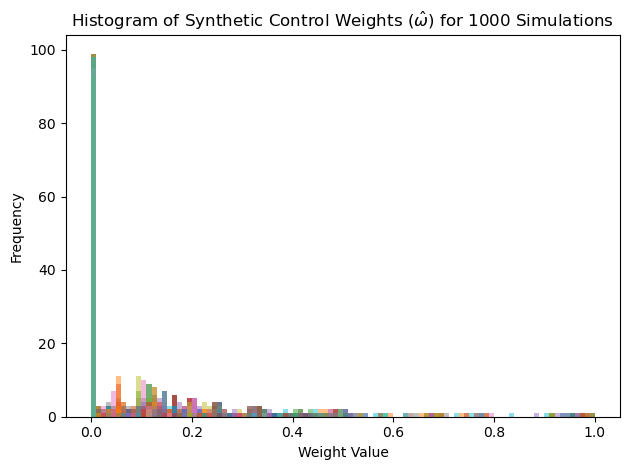

In [65]:
plt.figure(figsize=(17, 6))
result_df_plot.drop(columns=['features']).plot(kind='hist', bins=100, alpha=0.5)
plt.title(r'Histogram of Synthetic Control Weights ($\hat{\omega}$) for 1000 Simulations')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# saving the simulation in the directory simulations_ds
# result_df.to_csv( path2 + "/sc_weights_1000.csv", index=False)

Text(0, 0.5, 'Weight Value $\\hat{\\omega}$')

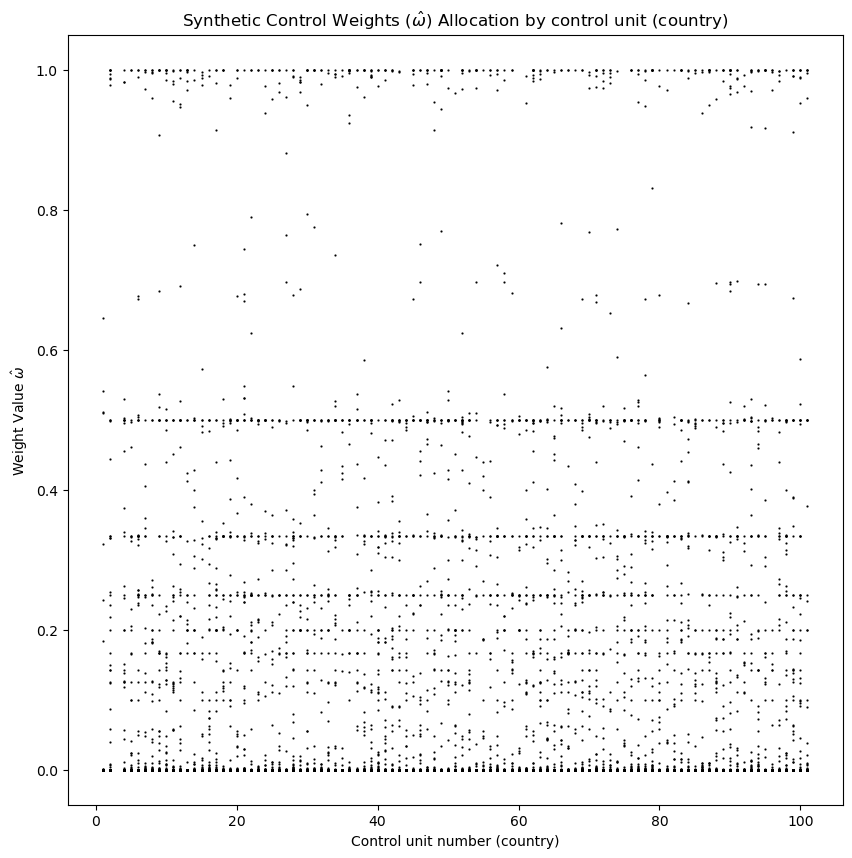

In [18]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x='features', y='value', data=result_df_plot.melt(id_vars='features'), 
                alpha=1, color='black', s=2, edgecolor='black')
plt.title(r'Synthetic Control Weights ($\hat{\omega}$) Allocation by control unit (country)')
plt.xlabel('Control unit number (country)')
plt.ylabel(r'Weight Value $\hat{\omega}$')

In [19]:
dd = pd.read_csv(path2 + "/sc_weights_1000.csv")
dd = dd.T
dd = dd.describe()
dd.loc['skewness'] = dd.skew()
dd.loc['kurtosis'] = dd.kurtosis()
dd.loc['median'] = dd.median()

dd = dd.iloc[1:]
dd = dd.T

aa = {
    'weights_mean': dd['mean'].mean(),
    'std': dd['std'].mean(),
    'skewness': dd['skewness'].mean(),
    'kurtosis': dd['kurtosis'].mean(),
    'median': dd['median'].mean()   
}
aa = pd.DataFrame(aa, index=['mean of all'])
aa


,weights_mean,std,skewness,kurtosis,median
mean of all,0.061419,1.630565,2.809768,8.911182,0.831493


In [ ]:
# aa.to_latex(path2 + "/sc_weights_1000_stats.tex")